# Linear Regression  (Assignment 1)
Predicting **Hot Coffee Sales (cups)** from **Temperature (C)** using only `numpy`.

In [1]:
!pip install matplotlib

In [20]:
import pandas as pd

df = pd.read_csv('coffee_sales_data.csv')

df.head()

,Temperature (°C),Hot Coffee Sales (cups)
0,10,180
1,12,165
2,14,150
3,16,140
4,18,120


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Data from the table (C1 = Temperature, C2 = Hot Coffee Sales)
temperature = np.array([10, 12, 14, 16, 18, 20, 22])
coffee_sales = np.array([180, 165, 150, 140, 120, 110, 95])

X = temperature   # independent variable
y = coffee_sales      # dependent variable

print(f"Number of data points: {len(X)}")

Number of data points: 7


## Fit the line: y = m*x + b
Using the least-squares formulas directly with numpy.

In [21]:
n = len(X)
x_mean = np.mean(X)
y_mean = np.mean(y)

# slope (m) and intercept (b)
m = np.sum((X - x_mean) * (y - y_mean)) / np.sum((X - x_mean) ** 2)
b = y_mean - m * x_mean

print(f"Slope (m): {m:.4f}")
print(f"Intercept (b): {b:.4f}")
print(f"Equation: coffee_sales = {m:.4f} * temperature + {b:.4f}")

Slope (m): -7.0536
Intercept (b): 250.0000
Equation: coffee_sales = -7.0536 * temperature + 250.0000


### Alternative: same result using `np.polyfit`

In [22]:
m2, b2 = np.polyfit(X, y, 1)
print(f"np.polyfit -> slope: {m2:.4f}, intercept: {b2:.4f}")

np.polyfit -> slope: -7.0536, intercept: 250.0000


## Evaluate the fit (R²)

In [23]:
y_pred = m * X + b
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y_mean) ** 2)
r_squared = 1 - ss_res / ss_tot

print(f"R-squared: {r_squared:.4f}")

R-squared: 0.9963


## Plot the data and the regression line

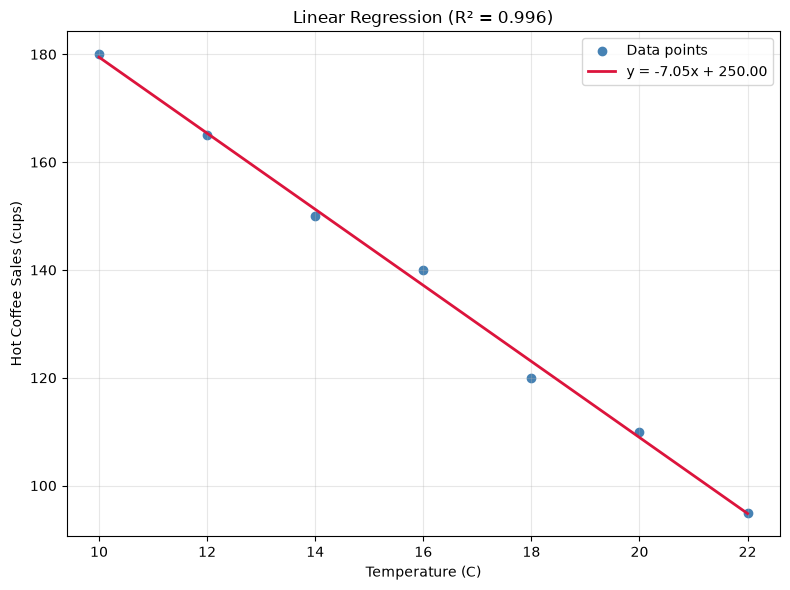

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='steelblue', label='Data points')

x_line = np.linspace(X.min(), X.max(), 100)
y_line = m * x_line + b
plt.plot(x_line, y_line, color='crimson', linewidth=2, label=f'y = {m:.2f}x + {b:.2f}')

plt.xlabel('Temperature (C)')
plt.ylabel('Hot Coffee Sales (cups)')
plt.title(f'Linear Regression (R² = {r_squared:.3f})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Predict a new value
Example: predict the coffee sales for a day when temperature is 15 degree celcius.

In [26]:
new_temperature = 15
predicted_sales = m * new_temperature + b
print(f"Predicted Coffee Sales for {new_temperature} degree Celcius Temperature: {predicted_sales:.2f} cups")

Predicted Coffee Sales for 15 degree Celcius Temperature: 144.20 cups
